In [1]:
import pandas as pd
import csv 
import geopandas as gpd
from datetime import timedelta
from shapely.geometry import Point
import glob
from shapely import wkt


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/Users/danalapides/opt/miniconda3/lib/python3.9/runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/Users/danalapides/opt/miniconda3/lib/python3.9/runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "/Users/danalapides/opt/miniconda3/lib/python3.9/site-packages/ipykernel_launcher.py", line 16, in <module>
    app.launch_new_instance()
  File "/Users/danalapides/opt/miniconda3/lib/python3.9/site-packages/traitlets/config/application.py", line 846, in la

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/Users/danalapides/opt/miniconda3/lib/python3.9/runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/Users/danalapides/opt/miniconda3/lib/python3.9/runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "/Users/danalapides/opt/miniconda3/lib/python3.9/site-packages/ipykernel_launcher.py", line 16, in <module>
    app.launch_new_instance()
  File "/Users/danalapides/opt/miniconda3/lib/python3.9/site-packages/traitlets/config/application.py", line 846, in la

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/Users/danalapides/opt/miniconda3/lib/python3.9/runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/Users/danalapides/opt/miniconda3/lib/python3.9/runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "/Users/danalapides/opt/miniconda3/lib/python3.9/site-packages/ipykernel_launcher.py", line 16, in <module>
    app.launch_new_instance()
  File "/Users/danalapides/opt/miniconda3/lib/python3.9/site-packages/traitlets/config/application.py", line 846, in la

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/Users/danalapides/opt/miniconda3/lib/python3.9/runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/Users/danalapides/opt/miniconda3/lib/python3.9/runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "/Users/danalapides/opt/miniconda3/lib/python3.9/site-packages/ipykernel_launcher.py", line 16, in <module>
    app.launch_new_instance()
  File "/Users/danalapides/opt/miniconda3/lib/python3.9/site-packages/traitlets/config/application.py", line 846, in la

AttributeError: _ARRAY_API not found

In [2]:
#read csv files and adjust to datetime

#imagery dates
R_im_date = pd.read_csv('../Data/'+#data/Ramsey/
                        'RamseyImageryDates.csv', parse_dates=['date'])
R_im_date['date'] = pd.to_datetime(R_im_date['date'])

#survey dates
R_sur_date = pd.read_csv('../Data/'+#data/Ramsey/
                         'RamseySurveyDates.csv', delimiter=';', index_col=False, parse_dates = ['Ramsey wet/dry date']) 
R_sur_date.rename(columns={'Ramsey wet/dry date':'date'}, inplace=True )
R_sur_date['date'] = pd.to_datetime(R_sur_date['date'], format = '%m/%d/%Y', errors = 'coerce')
R_sur_date = R_sur_date.dropna(subset = ['date'])

#hydrological data (precipitation and streamflow)
R_hyd = pd.read_csv('../data/Ramsey/RamseyHydroData.csv')
R_hyd.rename( columns={'Unnamed: 0':'date'}, inplace=True )
R_hyd['date'] = pd.to_datetime(R_hyd['date'])

#new precipitation file used later
R_precipitation = pd.read_csv('../Data/'+#data/Ramsey/
                              'daymet_precip.csv')
R_precipitation['system:time_start'] = pd.to_datetime(R_precipitation['system:time_start'])
R_precipitation.rename( columns={'00000000000000000000':'P','system:time_start':'day'}, inplace=True )

#surveydata with geometries having a wet/dry label, dates are only given in year
R_surveyData = pd.read_csv('../Data/'+#data/Ramsey/
                           'Ramsey_surveyData.csv')

R_sur_date = pd.concat([R_sur_date,pd.DataFrame.from_dict({'Unnamed: 0':[2024_1],
                                                           'date':[pd.to_datetime('2024-09-19')]})])


In [22]:
# R_surveyData

In [23]:
#find matching dates between survey and imagery
matching_dates = []
tolerance = timedelta(days = 5)

for date1 in R_sur_date['date']:
    exact_date = False
    tol = False 
    for date2 in R_im_date['date']:
        if date1 == date2:
            matching_dates.append({'Survey': date1, 'Imagery': date2})
            exact_date = True
    if not exact_date:
        for date2 in R_im_date['date']:
            if abs(date1 - date2) <= tolerance:
                matching_dates.append({'Survey': date1, 'Imagery': date2})
                tol = True
        if not tol: 
            for date2 in R_im_date['date']:
                if abs(date1-date2) < timedelta(days = 10): 
                    matching_dates.append({'Survey': date1, 'Imagery': date2})


matching_df = pd.DataFrame(matching_dates)


In [24]:
R_datessurData = pd.merge(matching_df, R_hyd, left_on = 'Survey', right_on = 'date', how = 'left')
R_datesimData = pd.merge(matching_df, R_hyd, left_on = 'Imagery', right_on = 'date')
#R_datessurData = R_datessurData.drop(columns = ['Imagery','date'])
#R_datesimData = R_datesimData.drop(columns = ['Survey','date'])


In [25]:
#sum precipitation for dates in between survey and imagery
def sum_pdatesbetween(d1, d2):
    r = pd.date_range(start=min(d1,d2), end=max(d1,d2))
    return R_hyd[R_hyd['date'].isin(r)]['P [mm]'].sum()

In [26]:
#making a dataframe to determine which imagery dates to use
Rh = pd.DataFrame([])

Rh['Survey'] = matching_df['Survey']
Rh['Imagery'] = matching_df['Imagery']
Rh['sum_P'] = [sum_pdatesbetween(R_datessurData.loc[i, 'Survey'], R_datesimData.loc[i, 'Imagery']) for i in range(len(Rh))]
Rh['Q_s-i'] = (R_datessurData['Q [mm/d]'] - R_datesimData['Q [mm/d]']) / R_datessurData['Q [mm/d]'] * 100
Rh['Use/not'] = ['use', 'use', 'use', 'use', 'not', 'not',
                 'not', 'use', 'not', 'use'] 

Rh = Rh.fillna('')

conditions = (Rh['Use/not'] == 'not')

Rh = Rh[~conditions]

Rh = Rh.drop(columns=['Use/not'])

Rh

,Survey,Imagery,sum_P,Q_s-i
0,2018-06-23,2018-06-23,0.000000,
1,2019-06-15,2019-06-15,0.000000,0.0
2,2020-06-15,2020-06-15,0.931333,0.0
3,2021-06-16,2021-06-16,0.000000,
7,2022-06-12,2022-06-13,0.000000,
9,2023-06-13,2023-06-13,0.000000,0.0


In [27]:
Rh.to_csv('../data/Ramsey/Ramsey_survey_imagery_hydro.csv', index = 'False')

In [28]:
#First adjusting the dates in surveyData, as they are only logged with the respective year and not exact date
R_sur_date['Year'] = R_sur_date['date'].dt.year
R_surveyData['Year'] = R_surveyData['Year'].astype(int)
Rdata = pd.merge(R_surveyData, R_sur_date[['date', 'Year']], on = 'Year', how = 'left')
Rdata = Rdata.drop(columns=['Year', 'Unnamed: 0'])
Rdata.rename(columns = {'date':'Year'}, inplace = True)
Rdata = Rdata.drop_duplicates()
Rdata

,geometry,wetdry,Year
0,POINT (565743.2846125544 3479369.0827875617),dry,2020-06-15
1,POINT (565746.5149411468 3479372.8991965),dry,2020-06-15
2,POINT (565749.7452697393 3479376.715605438),dry,2020-06-15
3,POINT (565752.9755983318 3479380.5320143765),dry,2020-06-15
4,POINT (565756.2059269242 3479384.348423315),dry,2020-06-15
...,...,...,...
16340,POINT (563659.344919984 3475987.92336578),wet,2023-06-13
16341,POINT (563661.0168714823 3475992.3050270467),wet,2023-06-13
16342,POINT (563660.9864038306 3475997.304934218),wet,2023-06-13
16343,POINT (563662.3442858508 3476001.800653563),wet,2023-06-13


In [29]:
#survey data with dates into a geodataframe and adding x and y from the geometry to 
#facilitate merge

Rdata['geometry'] = Rdata['geometry'].apply(wkt.loads)
gdf = gpd.GeoDataFrame(Rdata, geometry = 'geometry')#, crs='EPSG:26912')

gdf['x'] = gdf.geometry.x
gdf['y'] = gdf.geometry.y
gdf = gdf[['geometry', 'x', 'y', 'wetdry', 'Year']]
#gdf['Year'] = gdf['Year'].astype(int) 
#gdf['Year'] = pd.to_datetime(gdf['Year'])
gdf

,geometry,x,y,wetdry,Year
0,POINT (565743.285 3479369.083),565743.284613,3.479369e+06,dry,2020-06-15
1,POINT (565746.515 3479372.899),565746.514941,3.479373e+06,dry,2020-06-15
2,POINT (565749.745 3479376.716),565749.745270,3.479377e+06,dry,2020-06-15
3,POINT (565752.976 3479380.532),565752.975598,3.479381e+06,dry,2020-06-15
4,POINT (565756.206 3479384.348),565756.205927,3.479384e+06,dry,2020-06-15
...,...,...,...,...,...
16340,POINT (563659.345 3475987.923),563659.344920,3.475988e+06,wet,2023-06-13
16341,POINT (563661.017 3475992.305),563661.016871,3.475992e+06,wet,2023-06-13
16342,POINT (563660.986 3475997.305),563660.986404,3.475997e+06,wet,2023-06-13
16343,POINT (563662.344 3476001.801),563662.344286,3.476002e+06,wet,2023-06-13


In [30]:
#Checking for perennial reaches by comparing surveys of each year

gdf = gdf.set_geometry('geometry')#, crs='EPSG:26912')
#gdf['geometry'] = gdf['geometry'].apply(wkt.loads)
#gdf['geometry_wkt'] = gdf['geometry'].apply(lambda geom: geom.wkt)

perennial = pd.DataFrame(gdf.groupby('geometry')['wetdry'].apply(lambda x: sum(x == 'wet'))).reset_index(drop=False)

# whichever number is reasonable based on data?
perennial = perennial[(perennial['wetdry'] == 6)]

#assume always wet
perennial = perennial.assign(wetdry = 'wet')
#perennial['geometry'] = perennial['geometry_wkt'].apply(wkt.loads)
#perennial = perennial.drop(columns=['geometry_wkt'])

#perennial['geometry'] = perennial['geometry'].apply(wkt.loads)
gdf_perennial = gpd.GeoDataFrame(perennial, geometry = 'geometry')#, crs='EPSG:26912')
gdf_perennial['x'] = gdf_perennial.geometry.x
gdf_perennial['y'] = gdf_perennial.geometry.y

#making the gdf matching the perennial reaches to the imagery dates available 
imagery_perennial = pd.concat([gdf_perennial.assign(imagery = date) for date in R_im_date['date']], ignore_index=True)
imagery_perennial = imagery_perennial[~imagery_perennial['imagery'].isin(Rh['Imagery'])]
imagery_perennial['assumption'] = len(imagery_perennial)*['assumed perennial']
imagery_perennial

,geometry,wetdry,x,y,imagery,assumption
0,POINT (563355.463 3476891.197),wet,563355.462505,3.476891e+06,2016-07-22,assumed perennial
1,POINT (563350.463 3476891.166),wet,563350.462597,3.476891e+06,2016-07-22,assumed perennial
2,POINT (563358.997 3476894.364),wet,563358.996712,3.476894e+06,2016-07-22,assumed perennial
3,POINT (563362.228 3476898.18),wet,563362.228387,3.476898e+06,2016-07-22,assumed perennial
4,POINT (563355.463 3476891.197),wet,563355.462505,3.476891e+06,2016-08-28,assumed perennial
...,...,...,...,...,...,...
4635,POINT (563362.228 3476898.18),wet,563362.228387,3.476898e+06,2024-03-27,assumed perennial
4636,POINT (563355.463 3476891.197),wet,563355.462505,3.476891e+06,2024-03-28,assumed perennial
4637,POINT (563350.463 3476891.166),wet,563350.462597,3.476891e+06,2024-03-28,assumed perennial
4638,POINT (563358.997 3476894.364),wet,563358.996712,3.476894e+06,2024-03-28,assumed perennial


<Axes: >

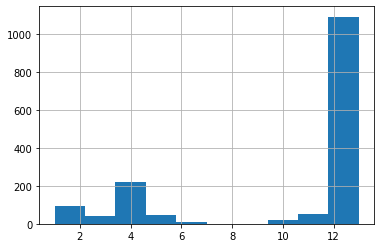

In [31]:
gdf.groupby('geometry').count().wetdry.hist()

In [32]:
# merging to be able to use the new precipitation data
R_new_hyd = R_hyd.merge( R_precipitation, left_on = 'date', right_on = 'day')
R_new_hyd = R_new_hyd.drop(columns = ['day', 'P [mm]'])
R_new_hyd.rename( columns={'P':'P [mm]'}, inplace=True )
R_new_hyd.set_index(['date'], drop =True, inplace = True)
R_new_hyd

,Q [mm/d],P [mm]
date,,
2016-01-01,0.000481,0.00
2016-01-02,0.000481,0.00
2016-01-03,0.000481,0.00
2016-01-04,0.000682,16.30
2016-01-05,0.000662,4.45
...,...,...
2023-12-27,0.000000,0.00
2023-12-28,0.000000,0.00
2023-12-29,0.000000,0.00


In [33]:
#function to define assumptions around dates to choose, based on streamflow and precipitation
def tolerance(Q_P_data, date, start, adjust, tolerance_p, P_condition = -999, Q_condition = -999):
    
    sub_grupp = Q_P_data.copy()
    
    if adjust == 'start':      
        sub_grupp = Q_P_data.loc[start:].copy()       
        
    elif adjust == 'end': #reverse index to loop backwards
        sub_grupp = sub_grupp.loc[:start].copy().iloc[::-1]        
    
    else:
        print('Invalid adjust parameter. Please use "start" or "end"')
        return

    
    # Reset index if reversed
    sub_grupp.reset_index(inplace=True)
     
    sub_grupp['Q_diff'] = sub_grupp['Q [mm/d]'].diff().fillna(0)

    if adjust == 'start':
        sub_grupp['tolerance_condition'] = (sub_grupp.Q_diff < tolerance_p * sub_grupp['Q [mm/d]'])

    if adjust == 'end':
        sub_grupp['tolerance_condition'] = (sub_grupp.Q_diff > -tolerance_p * sub_grupp['Q [mm/d]'])
    
    if P_condition == -999 == Q_condition:
        print('not a valid condition')
        return 
        
    elif P_condition == -999:
        if Q_condition > 0:
            sub_grupp['condition'] = sub_grupp['Q [mm/d]'] > Q_condition
        else:
            sub_grupp['condition'] = sub_grupp['Q [mm/d]'] < -Q_condition
            
    elif Q_condition == -999:
        if P_condition > 0:
            sub_grupp['condition'] = sub_grupp['P [mm]'] > P_condition
        else:
            sub_grupp['condition'] = sub_grupp['P [mm]'] < -P_condition
            
    else:
        if (Q_condition > 0) & (P_condition > 0):
            sub_grupp['condition'] = (sub_grupp['Q [mm/d]'] > Q_condition) & (sub_grupp['P [mm]'] > P_condition)
        elif (Q_condition < 0) & (P_condition > 0):
            sub_grupp['condition'] = (sub_grupp['Q [mm/d]'] < -Q_condition) & (sub_grupp['P [mm]'] > P_condition)           
        elif (Q_condition > 0) & (P_condition < 0):
            sub_grupp['condition'] = (sub_grupp['Q [mm/d]'] > Q_condition) & (sub_grupp['P [mm]'] < -P_condition)            
        else:
            sub_grupp['condition'] = (sub_grupp['Q [mm/d]'] < -Q_condition) & (sub_grupp['P [mm]'] < -P_condition)

    #where conditions are met
    yesgroup = sub_grupp[(sub_grupp['condition'] == True) & (sub_grupp['tolerance_condition'] == True)] 
       
  
    if len(yesgroup) == 0:
        print('No data where conditions are met')
        return pd.DataFrame()
        
    #where conditions are not met
    nogroup = sub_grupp[(sub_grupp['condition'] == False) | (sub_grupp['tolerance_condition'] == False)]  
    
    if len(nogroup) == 0:
        print('nogroup = 0')
        return sub_grupp.loc[yesgroup.index[0]:]

    if yesgroup.index[0] < nogroup.index[0]:
        print('everything is fine')
        return sub_grupp.loc[:nogroup.index[0]]
    
    else:
        print('No valid range found between yesgroup and nogroup indices')
        return pd.DataFrame()




In [34]:
#assumption of dry dates after the survey date while in a recession 


dry_list = []

for date in Rdata['Year'].unique():
    dry1 = tolerance(R_new_hyd, 'date', date, 'start', 0.05, Q_condition = -999, P_condition = -1)
    if len(dry1) == 0:
        print('dry1 is empty')
        continue
    dry1 = dry1[~dry1['date'].isin(Rh['Imagery'])]
    dry_imagery = pd.merge(dry1, R_im_date, on = ['date'], how = 'inner')
    #print(len(dry_imagery))
    dry_points = pd.DataFrame(gdf[gdf['Year']== (date)] .groupby('geometry')['wetdry'].apply(lambda x: (x == 'dry'))).reset_index(drop = False)
    dry_points = dry_points.assign(wetdry = 'dry')
    dry_im_points = [dry_points.assign(imagery = date) for date in dry_imagery['date']]
    #print(len(dry_im_points))
    
    try:
        dry = pd.concat(dry_im_points).drop(columns = ['level_1'])
        dry_list.append(dry)
    except:
        if len(dry_im_points)==0:
            print('No data for date '+ date.strftime('%Y-%m-%d'))
        else:
            dry = dry_im_points[0]
            dry_list.append(dry)
    #print(len(dry))
    

dry_df = pd.concat(dry_list)
dry_df['assumption'] = len(dry_df)*['assumed dry']




No valid range found between yesgroup and nogroup indices
dry1 is empty
everything is fine
No data for date 2016-06-21
everything is fine
No data for date 2014-06-19
everything is fine
No data for date 2009-06-15
No valid range found between yesgroup and nogroup indices
dry1 is empty
everything is fine
No data for date 2012-06-13
everything is fine
No data for date 2015-06-15
No valid range found between yesgroup and nogroup indices
dry1 is empty
everything is fine
No data for date 2013-06-11
No valid range found between yesgroup and nogroup indices
dry1 is empty
everything is fine
No data for date 2010-06-10
everything is fine
everything is fine


In [35]:
#assuming wet stretches for the dates before
#assumption is made with 5 % difference in streamflow and for dates before survey when in a recession 

wet_list = []

for date in Rdata['Year'].unique():
            
    wet1 = tolerance(R_new_hyd, 'date', date, 'end', 0.05, Q_condition = -999, P_condition = -1)
    if len(wet1) == 0:
        print('wet1 is empty')
        continue
    wet1 = wet1[~wet1['date'].isin(Rh['Imagery'])]
    wet_imagery = pd.merge(wet1, R_im_date, on = ['date'], how = 'inner')
    #print(len(wet_imagery))
    wet_points = pd.DataFrame(gdf[gdf['Year']== (date)].groupby('geometry')['wetdry'].apply(lambda x: sum(x == 'wet'))).reset_index(drop = False)
    wet_points = wet_points[~wet_points['geometry'].isin(perennial['geometry'])]
    wet_points = wet_points[(wet_points['wetdry'] == 1)]
    wet_points = wet_points.assign(wetdry = 'wet')
    wet_im_points = [wet_points.assign(imagery = date) for date in wet_imagery['date']]
        
    try:
        wet = pd.concat(wet_im_points).drop(columns = ['level_1'])
        wet_list.append(wet)
    except:
        if len(wet_im_points)==0:
            print('No data for date '+ date.strftime('%Y-%m-%d'))
        else:
            wet = wet_im_points[0]
            wet_list.append(wet)
        

wet_df = pd.concat(wet_list)


wet_df['assumption'] = len(wet_df)*['assumed wet']

No valid range found between yesgroup and nogroup indices
wet1 is empty
everything is fine
No data for date 2016-06-21
No data where conditions are met
wet1 is empty
No data where conditions are met
wet1 is empty
No valid range found between yesgroup and nogroup indices
wet1 is empty
No data where conditions are met
wet1 is empty
No data where conditions are met
wet1 is empty
No valid range found between yesgroup and nogroup indices
wet1 is empty
No data where conditions are met
wet1 is empty
No valid range found between yesgroup and nogroup indices
wet1 is empty
No data where conditions are met
wet1 is empty
everything is fine
everything is fine


In [36]:
#matching gdf with the imagery dates
gdf['assumption'] = len(gdf)*['survey/imagery match']
gdf_imagery = pd.merge(gdf, Rh, left_on = 'Year', right_on = 'Survey', how = 'left')
gdf_imagery = gdf_imagery.drop(columns=['Survey', 'sum_P', 'Q_s-i', 'Year'])
# merging all data, both survey and expanded data for wetdry assumption
all_expanded = pd.concat([gdf_imagery, imagery_perennial, dry_df, wet_df])
all_expanded = gpd.GeoDataFrame(all_expanded, geometry = 'geometry')#, crs='EPSG:26912')
all_expanded['x'] = all_expanded.geometry.x
all_expanded['y'] = all_expanded.geometry.y
all_expanded = all_expanded.rename(columns = {'imagery':'date_first'})
all_expanded['date'] = all_expanded['Imagery'].combine_first(all_expanded['date_first'])
all_expanded

,geometry,x,y,wetdry,assumption,Imagery,date_first,date
0,POINT (565743.285 3479369.083),565743.284613,3.479369e+06,dry,survey/imagery match,2020-06-15,NaT,2020-06-15
1,POINT (565746.515 3479372.899),565746.514941,3.479373e+06,dry,survey/imagery match,2020-06-15,NaT,2020-06-15
2,POINT (565749.745 3479376.716),565749.745270,3.479377e+06,dry,survey/imagery match,2020-06-15,NaT,2020-06-15
3,POINT (565752.976 3479380.532),565752.975598,3.479381e+06,dry,survey/imagery match,2020-06-15,NaT,2020-06-15
4,POINT (565756.206 3479384.348),565756.205927,3.479384e+06,dry,survey/imagery match,2020-06-15,NaT,2020-06-15
...,...,...,...,...,...,...,...,...
50,POINT (563652.409 3475960.509),563652.409226,3.475961e+06,wet,assumed wet,NaT,2023-06-08,2023-06-08
51,POINT (563650.114 3475956.354),563650.114415,3.475956e+06,wet,assumed wet,NaT,2023-06-08,2023-06-08
339,POINT (563216.942 3477123.096),563216.942275,3.477123e+06,wet,assumed wet,NaT,2023-06-08,2023-06-08
389,POINT (563213.444 3477126.384),563213.443925,3.477126e+06,wet,assumed wet,NaT,2023-06-08,2023-06-08


In [38]:
#reading and concatenating the processed imagery 
path = '../Data/'#data/Ramsey/processed_imagery_fehmida'#drawline'

processed_imagery = glob.glob(path + '/*.csv')
processed_imagery.sort(key = lambda x: int(x.split('_buffer_fehmida_')[1].split('.')[0]))

con_ready_imagery = []
for processed in processed_imagery:
    df= pd.read_csv(processed)
    con_ready_imagery.append(df)

concatenated = pd.concat(con_ready_imagery)

In [39]:
#turning the processed imagery into a gdf with x and y columns 
concatenated['geometry'] = concatenated['geometry'].apply(wkt.loads)
gdf_processed = gpd.GeoDataFrame(concatenated, geometry = 'geometry')#, crs='EPSG:26912')
gdf_processed['date'] = pd.to_datetime(gdf_processed['date'], format='%Y%m%d')
gdf_processed['x'] = gdf_processed.geometry.x
gdf_processed['y'] = gdf_processed.geometry.y
gdf_processed = gdf_processed.drop_duplicates()
gdf_processed

,blue,green,red,NIR,missing,NDWI,p,date,geometry,x,y
0,15.11,299.67,311.22,2184.89,0,-0.76,0,2023-11-06,POINT (565743.285 3479369.083),565743.284613,3.479369e+06
1,9.56,309.89,323.56,2158.56,0,-0.75,0,2023-11-06,POINT (565746.515 3479372.899),565746.514941,3.479373e+06
2,15.89,358.44,373.33,2458.33,0,-0.75,0,2023-11-06,POINT (565749.745 3479376.716),565749.745270,3.479377e+06
3,37.33,425.78,424.11,2701.22,0,-0.73,0,2023-11-06,POINT (565752.976 3479380.532),565752.975598,3.479381e+06
4,67.89,486.89,485.00,2952.67,0,-0.72,0,2023-11-06,POINT (565756.206 3479384.348),565756.205927,3.479384e+06
...,...,...,...,...,...,...,...,...,...,...,...
210250,191.78,437.11,646.89,2200.44,0,-0.67,0,2018-05-03,POINT (564501.874 3477768.345),564501.874014,3.477768e+06
210251,233.00,475.78,667.89,2368.00,0,-0.67,0,2018-05-03,POINT (564505.105 3477772.161),564505.105106,3.477772e+06
210252,291.33,532.89,722.89,2500.44,0,-0.65,0,2018-05-03,POINT (564508.336 3477775.976),564508.336198,3.477776e+06
210253,324.00,558.22,765.67,2507.11,0,-0.64,0,2018-05-03,POINT (564511.567 3477779.792),564511.567290,3.477780e+06


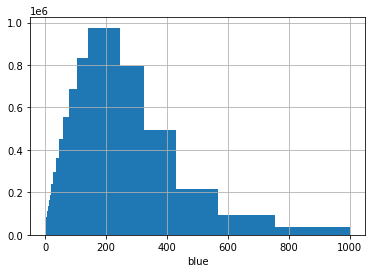

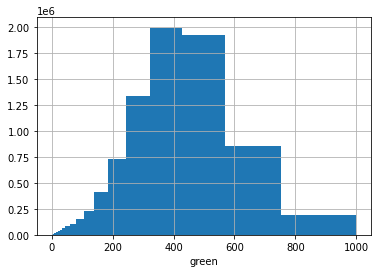

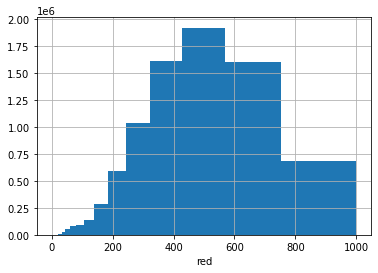

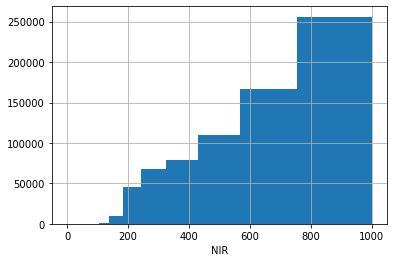

In [40]:
import numpy as np
import matplotlib.pyplot as plt
for col in ['blue','green','red','NIR']:
    gdf_processed[gdf_processed.red>0].dropna()[col].hist(bins = np.logspace(-3,3))
    plt.xlabel(col)
    plt.show()

In [41]:
precision = 5
all_expanded['x'] = all_expanded['x'].round(precision)
all_expanded['y'] = all_expanded['y'].round(precision)
gdf_processed['x'] = gdf_processed['x'].round(precision)
gdf_processed['y'] = gdf_processed['y'].round(precision)

In [42]:
merged = all_expanded.merge(gdf_processed, on=['date', 'x', 'y'])
#merge isn't working so performing a nearest spatial joing
if len(merged) == 0:
    print("Merge returned empty. Doing a spatial join based on proximity.")
    # using the smallest distance that worked
    result = gpd.sjoin_nearest(all_expanded, gdf_processed, how='inner', max_distance=0.4) 
    # filtering so all dates also match from the two gdfs
    result = result[result['date_left'] == result['date_right']]
    result = result.drop(columns = ['geometry', 'x_right', 'y_right', 'date_right', 'index_right', 'Imagery', 'date_first'])
else:
    result = merged

In [45]:
result_sorted

,geometry_x,x,y,wetdry,assumption,Imagery,date_first,date,blue,green,red,NIR,missing,NDWI,p,geometry_y
12799,POINT (563355.463 3476891.197),563355.46251,3.476891e+06,wet,assumed perennial,NaT,2016-07-22,2016-07-22,176.78,432.67,564.89,2828.56,0,-0.73,0,POINT (563355.463 3476891.197)
12800,POINT (563350.463 3476891.166),563350.46260,3.476891e+06,wet,assumed perennial,NaT,2016-07-22,2016-07-22,219.44,476.00,589.67,3009.33,0,-0.73,0,POINT (563350.463 3476891.166)
12801,POINT (563358.997 3476894.364),563358.99671,3.476894e+06,wet,assumed perennial,NaT,2016-07-22,2016-07-22,182.11,429.56,567.44,2646.67,0,-0.72,0,POINT (563358.997 3476894.364)
12802,POINT (563362.228 3476898.18),563362.22839,3.476898e+06,wet,assumed perennial,NaT,2016-07-22,2016-07-22,211.22,438.11,593.11,2446.44,0,-0.70,0,POINT (563362.228 3476898.18)
12806,POINT (563362.228 3476898.18),563362.22839,3.476898e+06,wet,assumed perennial,NaT,2016-08-28,2016-08-28,188.89,416.89,550.22,2533.22,0,-0.72,0,POINT (563362.228 3476898.18)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20407,POINT (563355.463 3476891.197),563355.46251,3.476891e+06,wet,assumed perennial,NaT,2024-03-28,2024-03-28,210.56,391.22,454.22,1791.67,0,-0.64,0,POINT (563355.463 3476891.197)
20406,POINT (563355.463 3476891.197),563355.46251,3.476891e+06,wet,assumed perennial,NaT,2024-03-28,2024-03-28,103.22,342.11,400.11,1850.00,0,-0.69,0,POINT (563355.463 3476891.197)
20405,POINT (563355.463 3476891.197),563355.46251,3.476891e+06,wet,assumed perennial,NaT,2024-03-28,2024-03-28,222.44,405.67,466.78,1776.22,0,-0.63,0,POINT (563355.463 3476891.197)
20411,POINT (563350.463 3476891.166),563350.46260,3.476891e+06,wet,assumed perennial,NaT,2024-03-28,2024-03-28,249.00,450.44,514.22,1954.44,0,-0.63,0,POINT (563350.463 3476891.166)


In [44]:
# try:
result = result.rename(columns = {'x_left':'x', 'y_left':'y', 'date_left':'date'})#.drop(columns='Imagery')
result_sorted = result.sort_values(by='date')
result_sorted = result_sorted.drop_duplicates()
# result_sorted.dropna(inplace = True)
result_sorted = result_sorted[~(result_sorted.NDWI.isna())]
result_sorted.assumption.unique()

array(['assumed perennial', 'survey/imagery match', 'assumed wet',
       'assumed dry'], dtype=object)

In [46]:
result_sorted.to_csv('../data/Ramsey/processed_assumptions/processed_with_dates_and_assumptions_fehmida.csv', encoding='utf-8', index=False)

In [47]:
#in case geometry gets fixed and the file increases in size as a result 
#start = 0
#splitnum = ?
#for i in range(1,splitnum+1):
#    newstart = int(len(result_sorted)/splitnum*i)
#    result_sorted.iloc[start:newstart].to_csv('../data/Ramsey/processed_assumptions/processed_with_dates_and_assumptions'+str(i)+'.csv',index=False,
#                      float_format='%.2f')
#    start = newstart



In [48]:
result_sorted.assumption.unique()

array(['assumed perennial', 'survey/imagery match', 'assumed wet',
       'assumed dry'], dtype=object)

<Axes: >

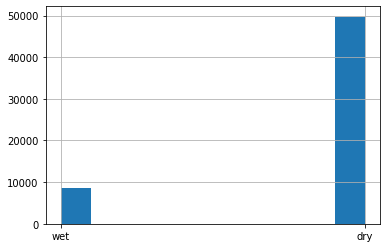

In [49]:
result_sorted.wetdry.hist()